# From 1D to 2D Gaussian

**Three ideas to hold onto throughout this notebook:**

1. **Sampling = shift + scale of a standard normal.** You never sample `N(μ, σ²)` directly — you sample `ε ~ N(0,1)` and compute `y = μ + σε`. The standard normal is the atom; everything else is a transformation of it.
2. **A 2D isotropic Gaussian is just two independent 1D Gaussians stacked.** There is no new magic — you run the 1D recipe twice, once per coordinate.
3. **The covariance matrix Σ sets the shape of the cloud.** Diagonal entries control per-axis spread; off-diagonal entries tilt the cloud by coupling the coordinates.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, ConnectionPatch
from matplotlib.lines import Line2D
from scipy.stats import norm, multivariate_normal
import os

# Reproducibility
RNG = np.random.default_rng(42)

# Output directory for saved figures
FIG_DIR = "./figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Palette
C_SAMPLE = "#4C72B0"   # muted blue  - sample points / histograms
C_ACCENT = "#DD8452"   # warm orange - means, contours, density curves
C_SHADE  = "#AEC6E8"   # light blue  - +-sigma band

# Global style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        False,
    "font.size":        12,
    "axes.titlesize":   14,
    "axes.labelsize":   12,
})

---
## Figure 1 — 1D Gaussian as "shift + scale of a standard normal"

The recipe is: draw `ε ~ N(0, 1)`, then compute `y = μ + σε`.

- **Multiplying by σ** stretches (or shrinks) the cloud — it scales the spread.
- **Adding μ** slides the whole cloud along the axis — it shifts the center.

The left panel shows the raw `ε` samples. The right panel shows the *same samples* after the `×σ, then +μ` transformation. Every point on the right is traceable to a point on the left.

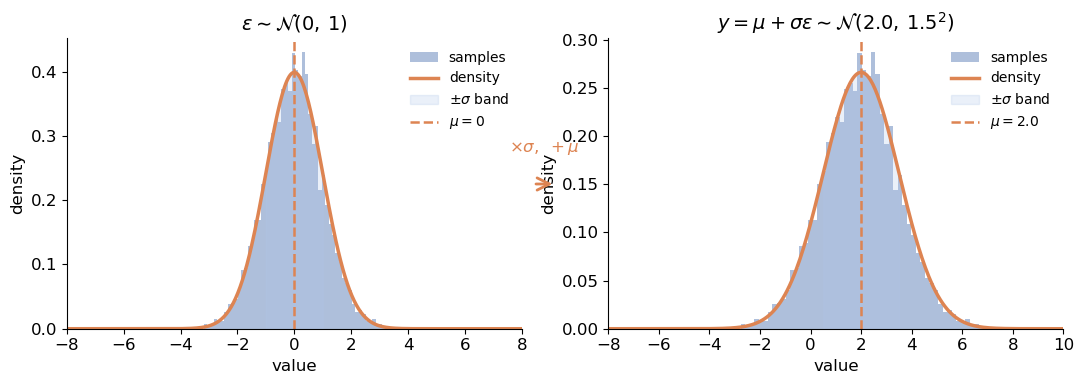

In [2]:
MU, SIGMA = 2.0, 1.5
N = 5_000

eps = RNG.standard_normal(N)
y   = MU + SIGMA * eps

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

panel_cfg = [
    (eps, 0,  1,      r"$\varepsilon \sim \mathcal{N}(0,\,1)$",
     (-8, 8)),
    (y,  MU, SIGMA,
     rf"$y = \mu + \sigma\varepsilon \sim \mathcal{{N}}({MU},\,{SIGMA}^2)$",
     (- 8, MU + 8)),
]

for ax, (samples, mu, sigma, title, xlim) in zip(axes, panel_cfg):
    x_grid = np.linspace(*xlim, 400)

    ax.hist(samples, bins=60, density=True,
            color=C_SAMPLE, alpha=0.45, label="samples")
    ax.plot(x_grid, norm.pdf(x_grid, mu, sigma),
            color=C_ACCENT, lw=2.5, label="density")

    band_x = np.linspace(mu - sigma, mu + sigma, 200)
    ax.fill_between(band_x, norm.pdf(band_x, mu, sigma),
                    alpha=0.25, color=C_SHADE, label=r"$\pm\sigma$ band")
    ax.axvline(mu, color=C_ACCENT, lw=1.8, ls="--",
               label=rf"$\mu = {mu}$")

    ax.set_xlim(xlim)
    ax.set_title(title)
    ax.set_xlabel("value")
    ax.set_ylabel("density")
    ax.legend(fontsize=10, frameon=False)

# Arrow + label between panels
fig.patches.append(
    mpatches.FancyArrowPatch(
        (0.492, 0.52), (0.512, 0.52),
        transform=fig.transFigure,
        arrowstyle="->", mutation_scale=22,
        color=C_ACCENT, lw=2,
    )
)
fig.text(0.502, 0.60, r"$\times\sigma,\ +\mu$",
         ha="center", fontsize=12, color=C_ACCENT)

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig1_1d_shift_scale.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 2 — 2D = two independent 1D Gaussians (joint + marginals)

Going from 1D to 2D is simpler than it looks: just run the 1D recipe **independently** for each coordinate.

- `x₁ ~ N(μ₁, σ₁²)` — the horizontal coordinate  
- `x₂ ~ N(μ₂, σ₂²)` — the vertical coordinate  

Because they are independent, the joint density factors: `p(x₁, x₂) = p(x₁) · p(x₂)`. The result is a cloud whose projections onto each axis recover the original 1D Gaussians — shown in the marginal panels on the top and right.

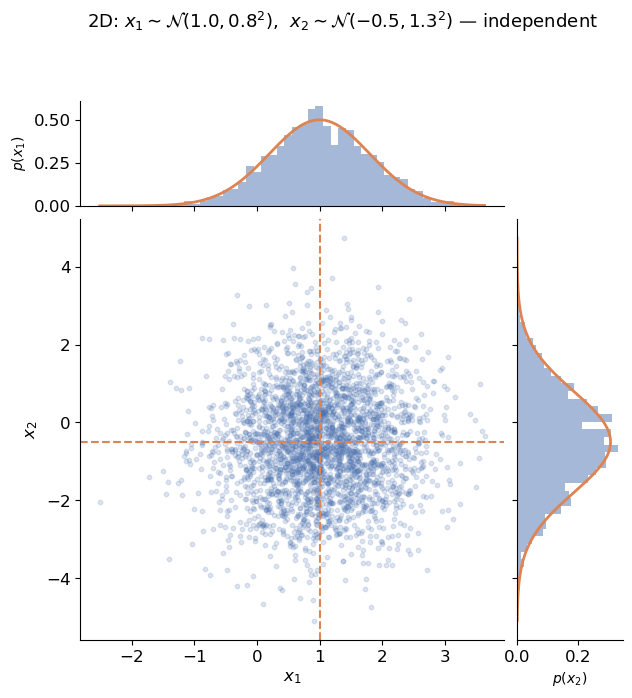

In [3]:
MU1, SIGMA1 = 1.0, 0.8
MU2, SIGMA2 = -0.5, 1.3
N2 = 3_000

x1 = MU1 + SIGMA1 * RNG.standard_normal(N2)
x2 = MU2 + SIGMA2 * RNG.standard_normal(N2)

fig = plt.figure(figsize=(7, 7))
gs  = fig.add_gridspec(2, 2,
                        width_ratios=[4, 1], height_ratios=[1, 4],
                        hspace=0.05, wspace=0.05)
ax_joint = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_joint)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

# Central scatter
ax_joint.scatter(x1, x2, alpha=0.18, s=10, color=C_SAMPLE, rasterized=True)
ax_joint.axvline(MU1, color=C_ACCENT, lw=1.5, ls="--")
ax_joint.axhline(MU2, color=C_ACCENT, lw=1.5, ls="--")
ax_joint.set_xlabel(r"$x_1$")
ax_joint.set_ylabel(r"$x_2$")

# Top marginal (x1)
ax_top.hist(x1, bins=50, density=True, color=C_SAMPLE, alpha=0.5)
gx = np.linspace(x1.min(), x1.max(), 300)
ax_top.plot(gx, norm.pdf(gx, MU1, SIGMA1), color=C_ACCENT, lw=2)
ax_top.set_ylabel(r"$p(x_1)$", fontsize=10)
plt.setp(ax_top.get_xticklabels(), visible=False)
for sp in ["top", "right"]: ax_top.spines[sp].set_visible(False)

# Right marginal (x2)
ax_right.hist(x2, bins=50, density=True,
              color=C_SAMPLE, alpha=0.5, orientation="horizontal")
gy = np.linspace(x2.min(), x2.max(), 300)
ax_right.plot(norm.pdf(gy, MU2, SIGMA2), gy, color=C_ACCENT, lw=2)
ax_right.set_xlabel(r"$p(x_2)$", fontsize=10)
plt.setp(ax_right.get_yticklabels(), visible=False)
for sp in ["top", "right"]: ax_right.spines[sp].set_visible(False)

fig.suptitle(
    rf"2D: $x_1\sim\mathcal{{N}}({MU1},{SIGMA1}^2)$,  "
    rf"$x_2\sim\mathcal{{N}}({MU2},{SIGMA2}^2)$ — independent",
    y=1.01, fontsize=13)

fig.savefig(f"{FIG_DIR}/fig2_2d_joint_marginals.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 3 — The covariance matrix controls the cloud's shape

The covariance matrix **Σ** encodes three things at once:
- **Diagonal entries** `Σ₁₁ = σ₁²`, `Σ₂₂ = σ₂²`: how spread out each coordinate is independently.
- **Off-diagonal entries** `Σ₁₂ = ρσ₁σ₂`: how much the coordinates co-vary (correlation tilts the ellipse).

The **eigendecomposition** of Σ tells you exactly what shape to expect:
- **Eigenvectors** → the *principal axes* of the ellipse (its orientation).
- **Eigenvalues** → the *squared semi-axis lengths* (how far the ellipse extends in each direction).

Three cases below — identical axis limits, equal aspect ratio — so you can compare shapes head-to-head.

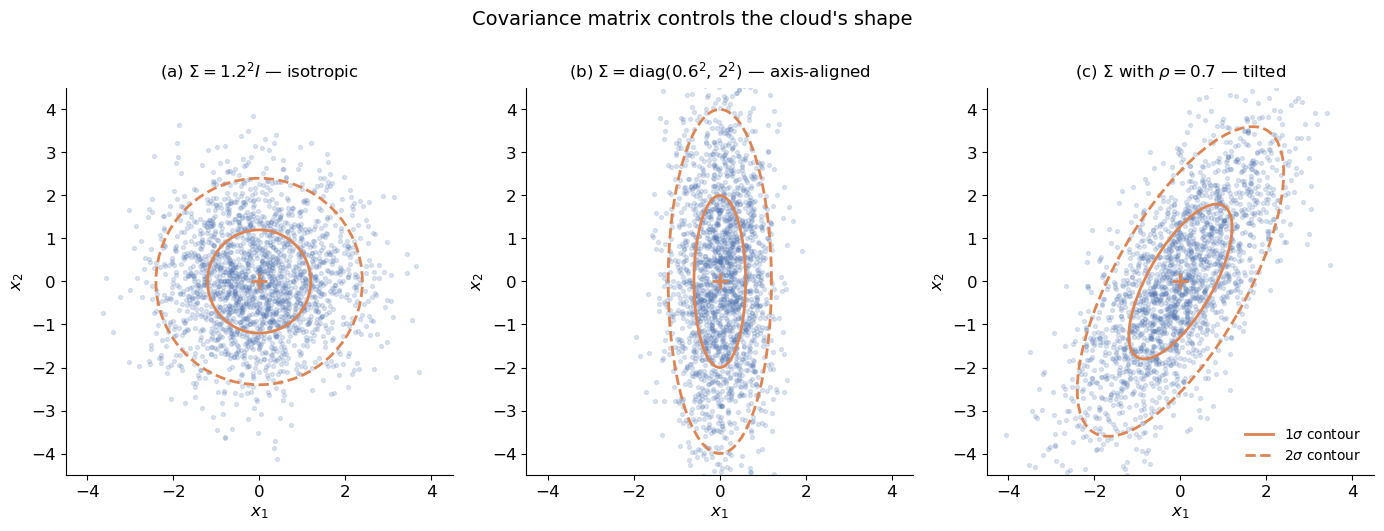

In [4]:
def plot_cov_ellipse(ax, mean, cov, n_std=(1, 2), color=C_ACCENT):
    """Overlay 1-sigma and 2-sigma ellipses via eigen-decomposition of cov."""
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    for k in n_std:
        ell = Ellipse(
            xy=mean,
            width=2 * k * np.sqrt(vals[-1]),
            height=2 * k * np.sqrt(vals[0]),
            angle=angle,
            edgecolor=color, facecolor="none",
            lw=2, ls="-" if k == 1 else "--",
        )
        ax.add_patch(ell)


N3   = 2_000
MEAN = np.zeros(2)
XLIM = YLIM = (-4.5, 4.5)

sig_iso = 1.2
cov_a = sig_iso**2 * np.eye(2)
cov_b = np.diag([0.6**2, 2.0**2])
rho_c, s1, s2 = 0.7, 1.2, 1.8
cov_c = np.array([[s1**2,        rho_c*s1*s2],
                  [rho_c*s1*s2,  s2**2      ]])

cases = [
    (cov_a, rf"(a) $\Sigma = {sig_iso}^2 I$ — isotropic"),
    (cov_b, r"(b) $\Sigma = \mathrm{diag}(0.6^2,\,2^2)$ — axis-aligned"),
    (cov_c, rf"(c) $\Sigma$ with $\rho = {rho_c}$ — tilted"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (cov, title) in zip(axes, cases):
    samples = RNG.multivariate_normal(MEAN, cov, N3)
    ax.scatter(samples[:, 0], samples[:, 1],
               alpha=0.18, s=8, color=C_SAMPLE, rasterized=True)
    plot_cov_ellipse(ax, MEAN, cov)
    ax.plot(*MEAN, marker="+", color=C_ACCENT, ms=12, mew=2)
    ax.set_xlim(XLIM); ax.set_ylim(YLIM)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")

legend_handles = [
    Line2D([0], [0], color=C_ACCENT, lw=2,       label=r"$1\sigma$ contour"),
    Line2D([0], [0], color=C_ACCENT, lw=2, ls="--", label=r"$2\sigma$ contour"),
]
axes[-1].legend(handles=legend_handles, fontsize=10, frameon=False, loc="lower right")

fig.suptitle("Covariance matrix controls the cloud's shape", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig3_cov_shapes.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 4 — 2D reparameterization (parallels Figure 1)

The same shift-and-scale recipe works in 2D:

$$\varepsilon \sim \mathcal{N}(\mathbf{0},\,I) \quad\longrightarrow\quad \mathbf{y} = \boldsymbol{\mu} + \sigma\,\varepsilon \sim \mathcal{N}(\boldsymbol{\mu},\,\sigma^2 I)$$

The **left panel** shows the standard normal cloud centered at the origin. The **right panel** shows the *exact same samples* after multiplying by σ and adding **μ** — the cloud shifts and scales rigidly. A handful of points are colored identically in both panels (with faint arrows) so you can follow individual samples through the transformation.

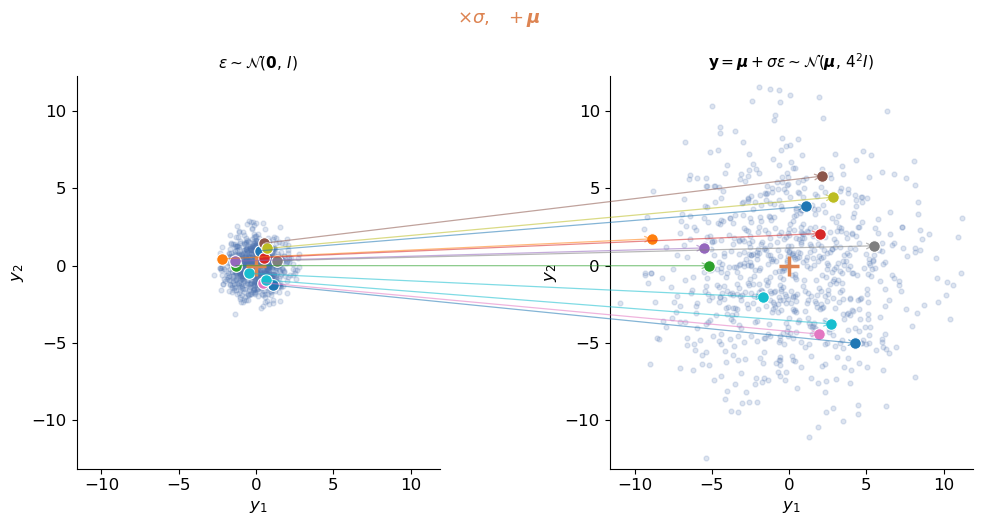

In [8]:
MU4    = np.array([0, 0])
SIGMA4 = 4
N4     = 800
N_HI   = 12

eps4 = RNG.standard_normal((N4, 2))
y4   = MU4 + SIGMA4 * eps4

# Shared axis limits that contain both clouds
all_pts = np.vstack([eps4, y4])
pad = 0.7
shared_xlim = (all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad)
shared_ylim = (all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad)

hi_idx  = np.linspace(0, N4 - 1, N_HI, dtype=int)
hi_cmap = plt.cm.tab10(np.linspace(0, 1, N_HI))

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 5))

panel_data = [
    (ax_l, eps4, np.zeros(2),
     r"$\varepsilon \sim \mathcal{N}(\mathbf{0},\,I)$"),
    (ax_r, y4,   MU4,
     rf"$\mathbf{{y}} = \boldsymbol{{\mu}} + \sigma\varepsilon \sim"
     rf"\mathcal{{N}}(\boldsymbol{{\mu}},\,{SIGMA4}^2 I)$"),
]

for ax, samples, center, title in panel_data:
    ax.scatter(samples[:, 0], samples[:, 1],
               alpha=0.18, s=12, color=C_SAMPLE, rasterized=True)
    for i, idx in enumerate(hi_idx):
        ax.scatter(samples[idx, 0], samples[idx, 1],
                   s=70, color=hi_cmap[i], zorder=5,
                   edgecolors="white", lw=0.8)
    ax.plot(*center, marker="+", color=C_ACCENT, ms=14, mew=2.5, zorder=6)
    ax.set_xlim(shared_xlim); ax.set_ylim(shared_ylim)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(r"$y_1$"); ax.set_ylabel(r"$y_2$")

# Faint arrows connecting corresponding highlighted points across panels
for i, idx in enumerate(hi_idx):
    con = ConnectionPatch(
        xyA=eps4[idx], coordsA=ax_l.transData,
        xyB=y4[idx],   coordsB=ax_r.transData,
        arrowstyle="->", color=hi_cmap[i],
        lw=0.9, alpha=0.55, mutation_scale=10,
    )
    fig.add_artist(con)

fig.text(0.5, 1.02, r"$\times\sigma,\ \ +\boldsymbol{\mu}$",
         ha="center", fontsize=13, color=C_ACCENT)

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig4_2d_reparam.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 5 (optional) — 3D surface of the 2D Gaussian density

The probability density of a 2D Gaussian is a **bell-shaped bump over the plane**. Its height at any point `(x₁, x₂)` equals `exp(-½ (x-μ)ᵀ Σ⁻¹ (x-μ))` (times a normalizing constant). The ellipses in Figure 3 are exactly the level curves of this surface viewed from above.

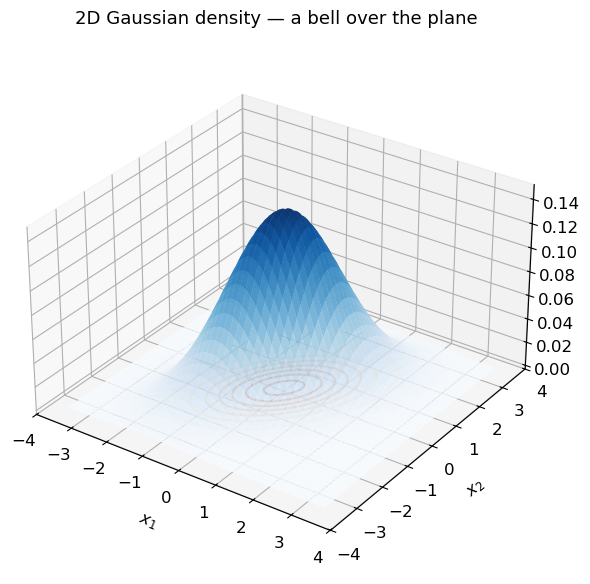

In [9]:
MEAN5 = np.zeros(2)
COV5  = np.array([[1.0, 0.6],
                  [0.6, 1.5]])

g = np.linspace(-3.5, 3.5, 150)
X1, X2 = np.meshgrid(g, g)
pos = np.dstack([X1, X2])
Z   = multivariate_normal(MEAN5, COV5).pdf(pos)

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection="3d")

ax.plot_surface(X1, X2, Z,
                cmap="Blues", alpha=0.85,
                linewidth=0, antialiased=True)
ax.contour(X1, X2, Z, levels=8,
           zdir="z", offset=0, cmap="Oranges", alpha=0.7)

ax.set_xlabel(r"$x_1$", labelpad=8)
ax.set_ylabel(r"$x_2$", labelpad=8)
ax.set_zlabel(r"$p(x_1,x_2)$", labelpad=8)
ax.set_title("2D Gaussian density — a bell over the plane", fontsize=13, pad=12)
ax.view_init(elev=30, azim=-55)
ax.set_box_aspect([1, 1, 0.6])

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig5_3d_density.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 6 (optional) — Interactive 2D Gaussian explorer

Drag the sliders to see how **μ**, **σ₁**, **σ₂**, and **ρ** reshape the cloud and its contour ellipses in real time.  
*(Requires `ipywidgets`; the cell degrades gracefully if it is not installed.)*

In [10]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAS_WIDGETS = True
except ImportError:
    _HAS_WIDGETS = False
    print("ipywidgets not installed — skipping interactive figure.")

if _HAS_WIDGETS:
    _RNG_W = np.random.default_rng(7)

    def draw_interactive(mu1=0.0, mu2=0.0, sigma1=1.0, sigma2=1.0, rho=0.0):
        rho  = float(np.clip(rho, -0.99, 0.99))
        mean = np.array([mu1, mu2])
        cov  = np.array([[sigma1**2,           rho*sigma1*sigma2],
                         [rho*sigma1*sigma2,   sigma2**2        ]])
        samp = _RNG_W.multivariate_normal(mean, cov, 1500)

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(samp[:, 0], samp[:, 1],
                   alpha=0.25, s=10, color=C_SAMPLE, rasterized=True)
        plot_cov_ellipse(ax, mean, cov)
        ax.plot(*mean, marker="+", color=C_ACCENT, ms=14, mew=2.5)

        lim = max(4*sigma1, 4*sigma2, 2) + 0.5
        ax.set_xlim(mu1 - lim, mu1 + lim)
        ax.set_ylim(mu2 - lim, mu2 + lim)
        ax.set_aspect("equal")
        ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
        ax.set_title(
            rf"$\boldsymbol{{\mu}}=({mu1:.1f},{mu2:.1f})$,  "
            rf"$\sigma_1={sigma1:.1f}$, $\sigma_2={sigma2:.1f}$, $\rho={rho:.2f}$",
            fontsize=12)
        plt.tight_layout()
        plt.show()

    ui = widgets.interactive(
        draw_interactive,
        mu1    = widgets.FloatSlider(min=-3,   max=3,    step=0.1,  value=0.0, description=r"mu1"),
        mu2    = widgets.FloatSlider(min=-3,   max=3,    step=0.1,  value=0.0, description=r"mu2"),
        sigma1 = widgets.FloatSlider(min=0.2,  max=3,    step=0.1,  value=1.0, description=r"sigma1"),
        sigma2 = widgets.FloatSlider(min=0.2,  max=3,    step=0.1,  value=1.0, description=r"sigma2"),
        rho    = widgets.FloatSlider(min=-0.99, max=0.99, step=0.01, value=0.0, description=r"rho"),
    )
    display(ui)
    fig

interactive(children=(FloatSlider(value=0.0, description='mu1', max=3.0, min=-3.0), FloatSlider(value=0.0, des…

---
## The Forward Noising Process — Destroying Structure One Step at a Time

We now connect the Gaussian building-blocks above to **diffusion models**.
A diffusion model's *forward process* is a Markov chain that gradually corrupts a data
point `x₀` by adding Gaussian noise over `T` steps, until all structure is erased.

Two versions exist with very different long-run behavior:

| Process | Update rule | Long-run variance |
|---|---|---|
| **Naive (variance-exploding)** | `x_t = x_{t-1} + σε` | grows as `σ²T → ∞` |
| **Variance-preserving (VP / DDPM)** | `x_t = √(1−β_t) x_{t-1} + √(β_t) ε` | stays pinned near **1** |

Only the VP process has a fixed, data-independent endpoint — `N(0, I)` — that we can
actually *generate from* by running a learned reverse chain.

In [94]:
from sklearn.datasets import make_s_curve
from scipy.stats import norm as sp_norm

# Dedicated RNG for the noising experiments — decoupled from Figures 1–5 above.
RNG_NOISE = np.random.default_rng(2024)

# Alternative 2D shapes (easy swaps for make_s_curve below):
#   make_moons(n_samples=2500, noise=0.0, random_state=42)   # two crescents
#   theta = np.linspace(0, 4*np.pi, 2500); r = theta / 12    # Archimedean spiral
X_raw, t_param = make_s_curve(n_samples=400, noise=0.0, random_state=42)
data_raw = X_raw[:, [0, 2]]   # keep x and z; drop y → 2D "S"

# Normalize per-coordinate to zero mean, unit variance.
# The VP process converges to N(0,I) only when the data is properly scaled —
# "variance pinned at 1" is literally true only after normalization.
data = (data_raw - data_raw.mean(axis=0)) / data_raw.std(axis=0)

# Fixed point colormap: position along the S parameter → color.
# This mapping never changes across plots, so structure-dissolution
# shows up as color scrambling rather than just point movement.
CMAP_DATA = plt.cm.plasma
t_norm_param = (t_param - t_param.min()) / (t_param.max() - t_param.min())
POINT_COLORS = CMAP_DATA(t_norm_param)

# Shared axis limits — wide enough to frame the clean S, tight enough
# that the exploding cloud is visibly overflowing.
AX_LIM = (-3.5, 3.5)


def scatter_snap(ax, pts, title, ax_lim=AX_LIM):
    """Scatter one 2D snapshot with fixed point colors and equal aspect."""
    ax.scatter(pts[:, 0], pts[:, 1],
               c=POINT_COLORS, s=50, alpha=0.75, rasterized=True)
    ax.set_aspect("equal")
    ax.set_xlim(ax_lim); ax.set_ylim(ax_lim)
    ax.set_title(title, fontsize=10, pad=4)
    ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")


print(f"data shape : {data.shape}")
print(f"per-coord mean : {data.mean(0).round(4)},  std : {data.std(0).round(4)}")

data shape : (400, 2)
per-coord mean : [0. 0.],  std : [1. 1.]


---
### Section A — A 2D shape to destroy

We use an **S-curve** from `sklearn.datasets.make_s_curve`, retaining coordinates 0 and 2
to get a 2D "S". `make_moons` and a spiral are equally valid shapes (see the comment in
the setup cell above).

Before corrupting anything we **normalize** the data: zero mean and unit variance per
coordinate. This matters because the VP process is designed to converge to `N(0, I)`, and
the "variance pinned at 1" property is literally true only when the data starts normalized.

Each point is colored by its position along the S-curve's underlying parameter. This
colormap is **fixed across every later plot** — as noise accumulates and the S dissolves,
the colors scramble while the geometry smears.

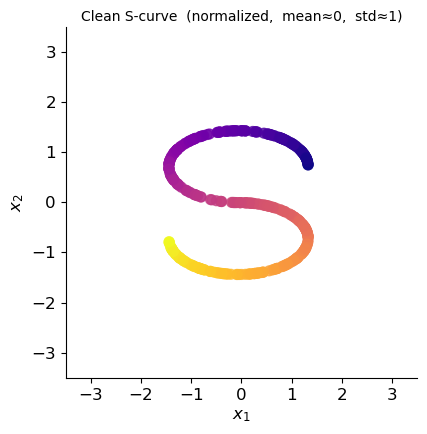

In [95]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
scatter_snap(ax, data, "Clean S-curve  (normalized,  mean≈0,  std≈1)")
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig6_clean_data.png", dpi=200, bbox_inches="tight")
plt.show()

---
### Section B — Naive forward process (variance-exploding)

The simplest thing you might try: add a small isotropic noise `σε` at every step.

$$x_t = x_{t-1} + \sigma\,\varepsilon, \qquad \varepsilon \sim \mathcal{N}(\mathbf{0},\,I)$$

Because this is just a running sum of independent Gaussians, variance **accumulates** —
each step adds `σ²` regardless of where you currently are:

$$\operatorname{Var}(x_t) = \operatorname{Var}(x_0) + t\,\sigma^2$$

The mean stays where it is, but the spread grows without bound. There is no fixed
endpoint to generate from. The five panels below share the **same axis limits** as the
clean data (±3.5), so you can see the cloud physically overflow the frame.

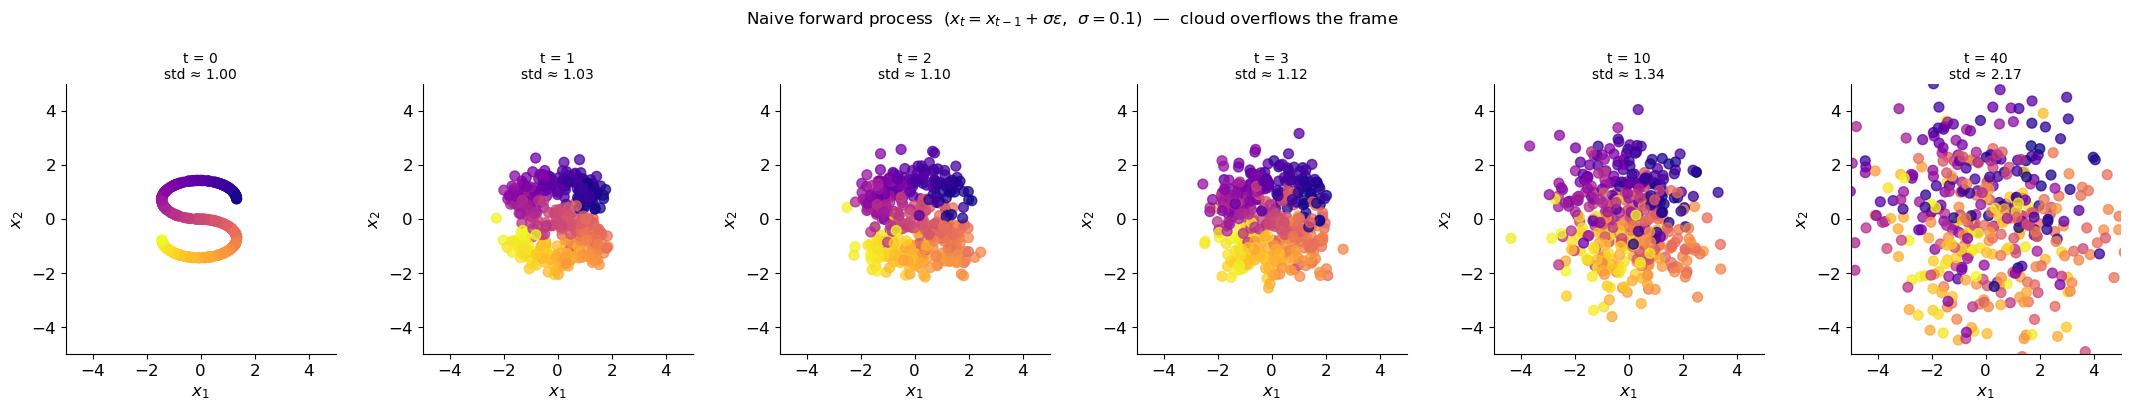

In [96]:
# ── Naive forward process ─────────────────────────────────────────────────────
SIGMA_N =  0.3    # noise scale per step
T_N     = 40    # total steps
SNAPS_N = [0, 1,2,3,10,40]

# Fixed plot limits
XLIM = (-5, 5)
YLIM = (-5, 5)

naive_snaps = {}
naive_std   = np.zeros(T_N + 1)   # mean per-coord empirical std at each step

x = data.copy()
naive_snaps[0] = x.copy()
naive_std[0]   = x.std(axis=0).mean()

for t in range(1, T_N + 1):
    eps = RNG_NOISE.standard_normal(x.shape)
    x = x + SIGMA_N * eps

    naive_std[t] = x.std(axis=0).mean()

    if t in SNAPS_N:
        naive_snaps[t] = x.copy()

# ── Scatter panel row ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(SNAPS_N), figsize=(3.6 * len(SNAPS_N), 3.8))

for ax, t in zip(axes, SNAPS_N):
    scatter_snap(
        ax,
        naive_snaps[t],
        f"t = {t}\nstd ≈ {naive_std[t]:.2f}"
    )

    ax.set_xlim(XLIM)
    ax.set_ylim(YLIM)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle(
    r"Naive forward process  ($x_t = x_{t-1} + \sigma\varepsilon$,  $\sigma = 0.1$)"
    "  —  cloud overflows the frame",
    fontsize=12,
    y=1.02,
)

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig7_naive_panels.png", dpi=200, bbox_inches="tight")
plt.show()

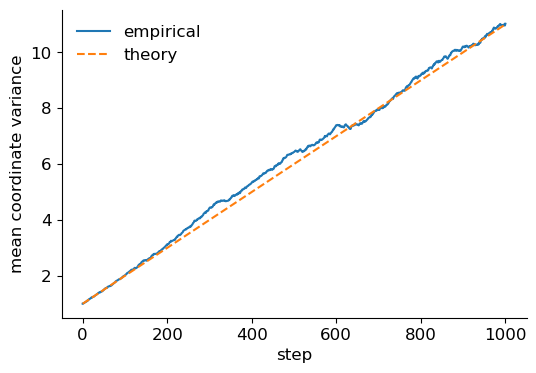

Saved files:
./figures/naive_forward_variance_increases.gif
./figures/naive_forward_variance_curve.png
Initial variance: 1.000
Final empirical variance: 11.023
Final theoretical variance: 11.000


In [97]:
# Variance increasing (free diffsuion) GIF for forward process

# naive forward diffusion GIF: variance keeps increasing

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ------------------------------------------------------------------------------
# Assumptions:
# - data:      numpy array of shape (N, 2)
# - RNG_NOISE: numpy random generator, e.g. np.random.default_rng(0)
# - FIG_DIR:   output directory
# ------------------------------------------------------------------------------

os.makedirs(FIG_DIR, exist_ok=True)

# ── Naive/free forward diffusion process ──────────────────────────────────────
T_N     = 1000
SIGMA_N = 0.10
DT      = 1.0

# Save only some steps for animation
FRAME_STEPS = list(range(0, T_N + 1, 10))
if FRAME_STEPS[-1] != T_N:
    FRAME_STEPS.append(T_N)

naive_frames = {}
naive_var    = np.zeros(T_N + 1)
naive_std    = np.zeros(T_N + 1)

x = data.copy()

naive_frames[0] = x.copy()
naive_var[0]    = x.var(axis=0).mean()
naive_std[0]    = x.std(axis=0).mean()

for t in range(1, T_N + 1):
    eps = RNG_NOISE.standard_normal(x.shape)

    # Euler-Maruyama for dx = sigma dW
    x = x + SIGMA_N * np.sqrt(DT) * eps

    naive_var[t] = x.var(axis=0).mean()
    naive_std[t] = x.std(axis=0).mean()

    if t in FRAME_STEPS:
        naive_frames[t] = x.copy()

times_forward = FRAME_STEPS

# ── Theoretical variance curve ────────────────────────────────────────────────
# Var(x_{t+1}) = Var(x_t) + sigma^2 * DT
var0 = naive_var[0]
theory_var = var0 + np.arange(T_N + 1) * (SIGMA_N ** 2) * DT

# ── Fixed plotting limits across all frames ───────────────────────────────────
all_pts = np.vstack([naive_frames[t] for t in FRAME_STEPS])

xmin, ymin = all_pts.min(axis=0)
xmax, ymax = all_pts.max(axis=0)

cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
half_range = max(xmax - xmin, ymax - ymin) / 2
half_range *= 1.10

xlim = (cx - half_range, cx + half_range)
ylim = (cy - half_range, cy + half_range)

# ── Helper functions ──────────────────────────────────────────────────────────
def setup_ax(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)


def make_forward_gif(times, out_path, fps=10):
    fig, ax = plt.subplots(figsize=(6, 6))

    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    setup_ax(ax)

    pts0 = naive_frames[times[0]]

    scat = ax.scatter(
        pts0[:, 0],
        pts0[:, 1],
        c=np.linspace(0, 1, len(pts0)),
        s=100,
        alpha=0.7,
        cmap="plasma",
        edgecolors="none"
    )

    def update(i):
        t = times[i]
        pts = naive_frames[t]
        scat.set_offsets(pts)
        return (scat,)

    anim = FuncAnimation(
        fig,
        update,
        frames=len(times),
        interval=100,
        blit=True
    )

    anim.save(
        out_path,
        writer=PillowWriter(fps=fps),
        savefig_kwargs={
            "bbox_inches": "tight",
            "pad_inches": 0
        }
    )

    plt.close(fig)


# ── Save forward GIF ──────────────────────────────────────────────────────────
forward_gif = os.path.join(FIG_DIR, "naive_forward_variance_increases.gif")
make_forward_gif(times_forward, forward_gif, fps=10)

# ── Save variance curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(np.arange(T_N + 1), naive_var, label="empirical")
ax.plot(np.arange(T_N + 1), theory_var, linestyle="--", label="theory")

ax.set_xlabel("step")
ax.set_ylabel("mean coordinate variance")
ax.legend(frameon=False)

variance_png = os.path.join(FIG_DIR, "naive_forward_variance_curve.png")
fig.savefig(variance_png, dpi=200, bbox_inches="tight")
plt.show()

print("Saved files:")
print(forward_gif)
print(variance_png)

print(f"Initial variance: {naive_var[0]:.3f}")
print(f"Final empirical variance: {naive_var[-1]:.3f}")
print(f"Final theoretical variance: {theory_var[-1]:.3f}")


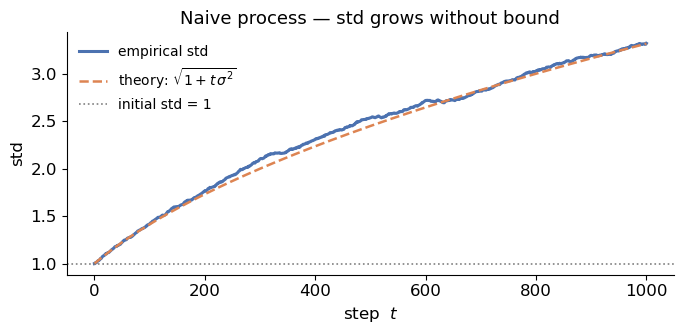

In [98]:
# ── Naive std-vs-t with closed-form overlay ───────────────────────────────────
t_arr_n      = np.arange(T_N + 1)
std_theory_n = np.sqrt(1 + t_arr_n * SIGMA_N**2)   # Var(x_t) = 1 + t·σ²

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t_arr_n, naive_std,      color=C_SAMPLE, lw=2.2, label="empirical std")
ax.plot(t_arr_n, std_theory_n,   color=C_ACCENT, lw=1.8, ls="--",
        label=r"theory: $\sqrt{1 + t\,\sigma^2}$")
ax.axhline(1, color="gray", lw=1.2, ls=":", label="initial std = 1")
ax.set_xlabel("step  $t$")
ax.set_ylabel("std")
ax.set_title("Naive process — std grows without bound", fontsize=13)
ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig8_naive_std_vs_t.png", dpi=200, bbox_inches="tight")
plt.show()

In [99]:
# naive forward diffusion GIF: cloud keeps expanding

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ------------------------------------------------------------------------------
# Assumptions:
# - data:      numpy array of shape (N, 2)
# - RNG_NOISE: numpy random generator, e.g. np.random.default_rng(0)
# - FIG_DIR:   output directory
# ------------------------------------------------------------------------------

os.makedirs(FIG_DIR, exist_ok=True)

# ── Naive/free diffusion process: dx = sigma dW_t ─────────────────────────────
T_N     = 1000
SIGMA_N = 0.30
DT      = 1.0

# Save only some steps for animation
FRAME_STEPS = list(range(0, T_N + 1, 10))
if FRAME_STEPS[-1] != T_N:
    FRAME_STEPS.append(T_N)

naive_frames = {}
naive_var    = np.zeros(T_N + 1)
naive_std    = np.zeros(T_N + 1)

x = data.copy()
naive_frames[0] = x.copy()
naive_var[0]    = x.var(axis=0).mean()
naive_std[0]    = x.std(axis=0).mean()

for t in range(1, T_N + 1):
    eps = RNG_NOISE.standard_normal(x.shape)

    # Euler-Maruyama update for dx = sigma dW_t
    x = x + SIGMA_N * np.sqrt(DT) * eps

    naive_var[t] = x.var(axis=0).mean()
    naive_std[t] = x.std(axis=0).mean()

    if t in FRAME_STEPS:
        naive_frames[t] = x.copy()

times_forward = FRAME_STEPS

# ── Fixed plotting limits across all frames ───────────────────────────────────
all_pts = np.vstack([naive_frames[t] for t in FRAME_STEPS])

xmin, ymin = all_pts.min(axis=0)
xmax, ymax = all_pts.max(axis=0)

cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
half_range = max(xmax - xmin, ymax - ymin) / 2
half_range *= 1.10

xlim = (cx - half_range, cx + half_range)
ylim = (cy - half_range, cy + half_range)

# ── Helper functions ──────────────────────────────────────────────────────────
def setup_ax(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)


def make_gif(times, out_path, fps=10):
    fig, ax = plt.subplots(figsize=(6, 6))

    # remove all figure padding
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    setup_ax(ax)

    pts0 = naive_frames[times[0]]

    scat = ax.scatter(
        pts0[:, 0],
        pts0[:, 1],
        c=np.linspace(0, 1, len(pts0)),
        s=100,
        alpha=0.7,
        cmap="plasma",
        edgecolors="none"
    )

    def update(i):
        t = times[i]
        pts = naive_frames[t]
        scat.set_offsets(pts)
        return (scat,)

    anim = FuncAnimation(
        fig,
        update,
        frames=len(times),
        interval=100,
        blit=True
    )

    anim.save(
        out_path,
        writer=PillowWriter(fps=fps),
        savefig_kwargs={
            "bbox_inches": "tight",
            "pad_inches": 0
        }
    )

    plt.close(fig)


# ── Forward GIF only ──────────────────────────────────────────────────────────
forward_gif = os.path.join(FIG_DIR, "naive_forward.gif")
make_gif(times_forward, forward_gif, fps=10)

print("Saved GIF:")
print(forward_gif)

print("\nVariance growth check:")
print(f"initial mean variance = {naive_var[0]:.4f}")
print(f"final mean variance   = {naive_var[-1]:.4f}")

Saved GIF:
./figures/naive_forward.gif

Variance growth check:
initial mean variance = 1.0000
final mean variance   = 86.6742


---
### Section C — The fix: variance-preserving (DDPM) forward process

One extra ingredient prevents the explosion: **shrink `x_{t-1}` by `√(1 − β_t)`** before
adding noise.

$$x_t = \sqrt{1 - \beta_t}\; x_{t-1} + \sqrt{\beta_t}\; \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(\mathbf{0},\,I)$$

The `√(1 − β_t)` shrink does **two jobs at once**:

1. **Caps the variance at 1.**
   `Var(x_t) = (1−β_t)·Var(x_{t-1}) + β_t·1 = Var(x_{t-1})` — variance is conserved at every step.

2. **Slowly erases `x₀`.**
   After `T` steps the shrink factors compound to ~0, so the chain forgets the data
   and converges to a round `N(0, I)` blob.

We use a **linear β schedule** from `β₁ ≈ 10⁻⁴` to `β_T = 0.02` over `T = 1000` steps.

**Closed form.** Because each step is a linear Gaussian, the whole chain collapses to a
single reparameterization — no iteration needed:

$$x_t = \sqrt{\bar{\alpha}_t}\; x_0 + \sqrt{1 - \bar{\alpha}_t}\; \varepsilon, \qquad
\bar{\alpha}_t = \prod_{s=1}^{t}(1 - \beta_s)$$

This is what makes diffusion training efficient: you can jump to *any* timestep in one
shot, without unrolling the chain.

Iterative std at t=1:   1.0357
Closed-form std at t=1: 1.0233


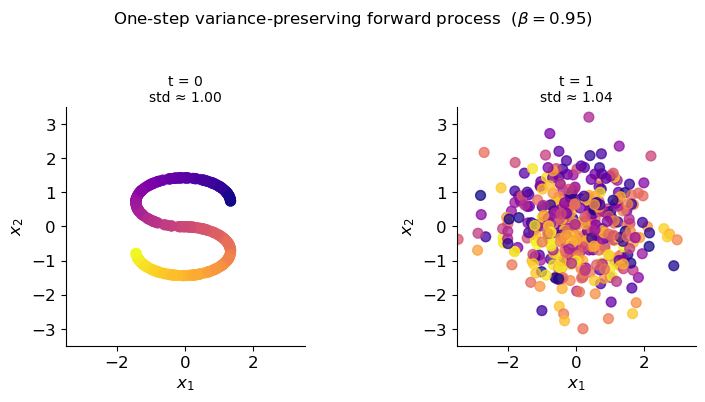

In [100]:
# for only one step:

# ── Variance-preserving forward process: one-step noise ──────────────────────

T_VP     = 1
BETA_VP  = 0.95
ALPHA_VP = 1.0 - BETA_VP

SNAPS_VP = [0, 1]

vp_snaps = {}
vp_std   = np.zeros(T_VP + 1)

# t = 0
x0 = data.copy()
vp_snaps[0] = x0.copy()
vp_std[0]   = x0.std(axis=0).mean()

# t = 1
eps = RNG_NOISE.standard_normal(x0.shape)
x1  = np.sqrt(ALPHA_VP) * x0 + np.sqrt(BETA_VP) * eps

vp_snaps[1] = x1.copy()
vp_std[1]   = x1.std(axis=0).mean()

# ── Closed-form sanity check ─────────────────────────────────────────────────
# For one step:
# x_1 = sqrt(1 - beta) x_0 + sqrt(beta) eps

eps_cf = RNG_NOISE.standard_normal(data.shape)
x_cf   = np.sqrt(ALPHA_VP) * data + np.sqrt(BETA_VP) * eps_cf

print(f"Iterative std at t=1:   {vp_std[1]:.4f}")
print(f"Closed-form std at t=1: {x_cf.std(axis=0).mean():.4f}")

# ── 2-panel scatter row ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))

for ax, t in zip(axes, SNAPS_VP):
    scatter_snap(
        ax,
        vp_snaps[t],
        f"t = {t}\nstd ≈ {vp_std[t]:.2f}"
    )

fig.suptitle(
    r"One-step variance-preserving forward process  ($\beta = 0.95$)",
    fontsize=12,
    y=1.04,
)

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig9_vp_one_step_beta095.png", dpi=200, bbox_inches="tight")
plt.show()


Iterative std at t=500:   1.0146
Closed-form std at t=500: 0.9995   ← should match


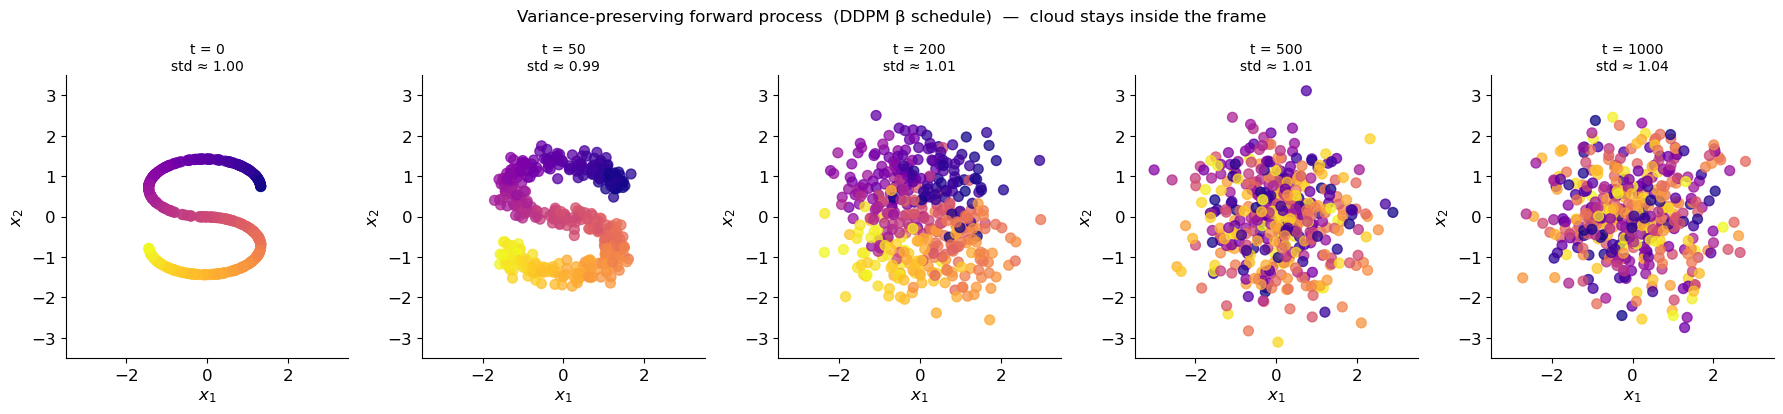

In [101]:
# ── Variance-preserving forward process ──────────────────────────────────────
T_VP      = 1000
BETA_VP   = np.linspace(1e-4, 0.02, T_VP)        # linear β schedule
ALPHA_VP  = 1.0 - BETA_VP
ALPHA_BAR = np.cumprod(ALPHA_VP)                  # ᾱ_t = ∏_{s≤t}(1 - β_s)

SNAPS_VP = [0, 50, 200, 500, T_VP]

vp_snaps = {}
vp_std   = np.zeros(T_VP + 1)

x = data.copy()
vp_snaps[0] = x.copy()
vp_std[0]   = x.std(axis=0).mean()

for t in range(1, T_VP + 1):
    eps      = RNG_NOISE.standard_normal(x.shape)
    x        = np.sqrt(ALPHA_VP[t - 1]) * x + np.sqrt(BETA_VP[t - 1]) * eps
    vp_std[t] = x.std(axis=0).mean()
    if t in SNAPS_VP:
        vp_snaps[t] = x.copy()

# ── Closed-form sanity check ──────────────────────────────────────────────────
# x_t = sqrt(ᾱ_t)·x_0 + sqrt(1−ᾱ_t)·ε  — should match the iterative result.
t_chk  = 500
eps_cf = RNG_NOISE.standard_normal(data.shape)
x_cf   = (np.sqrt(ALPHA_BAR[t_chk - 1]) * data
          + np.sqrt(1 - ALPHA_BAR[t_chk - 1]) * eps_cf)
print(f"Iterative std at t={t_chk}:   {vp_std[t_chk]:.4f}")
print(f"Closed-form std at t={t_chk}: {x_cf.std(axis=0).mean():.4f}   ← should match")

# ── 5-panel scatter row ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8))
for ax, t in zip(axes, SNAPS_VP):
    scatter_snap(ax, vp_snaps[t],
                 f"t = {t}\nstd ≈ {vp_std[t]:.2f}")

fig.suptitle(
    "Variance-preserving forward process  (DDPM β schedule)"
    "  —  cloud stays inside the frame",
    fontsize=12, y=1.02,
)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig9_vp_panels.png", dpi=200, bbox_inches="tight")
plt.show()

In [102]:
# forward and backward process GIFs

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ------------------------------------------------------------------------------
# Assumptions:
# - data:      numpy array of shape (N, 2)
# - RNG_NOISE: numpy random generator, e.g. np.random.default_rng(0)
# - FIG_DIR:   output directory
# ------------------------------------------------------------------------------

os.makedirs(FIG_DIR, exist_ok=True)

# ── Variance-preserving forward process ───────────────────────────────────────
T_VP      = 1000
BETA_VP   = np.linspace(1e-4, 0.02, T_VP)
ALPHA_VP  = 1.0 - BETA_VP
ALPHA_BAR = np.cumprod(ALPHA_VP)

# Save only some steps for animation
FRAME_STEPS = list(range(0, T_VP + 1, 10))
if FRAME_STEPS[-1] != T_VP:
    FRAME_STEPS.append(T_VP)

vp_frames = {}
vp_std    = np.zeros(T_VP + 1)

x = data.copy()
vp_frames[0] = x.copy()
vp_std[0]    = x.std(axis=0).mean()

for t in range(1, T_VP + 1):
    eps = RNG_NOISE.standard_normal(x.shape)
    x   = np.sqrt(ALPHA_VP[t - 1]) * x + np.sqrt(BETA_VP[t - 1]) * eps

    vp_std[t] = x.std(axis=0).mean()

    if t in FRAME_STEPS:
        vp_frames[t] = x.copy()

times_forward  = FRAME_STEPS
times_backward = FRAME_STEPS[::-1]

# ── Fixed plotting limits across all frames ───────────────────────────────────
all_pts = np.vstack([vp_frames[t] for t in FRAME_STEPS])

xmin, ymin = all_pts.min(axis=0)
xmax, ymax = all_pts.max(axis=0)

cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
half_range = max(xmax - xmin, ymax - ymin) / 2
half_range *= 1.10

xlim = (cx - half_range, cx + half_range)
ylim = (cy - half_range, cy + half_range)

# ── Helper functions ──────────────────────────────────────────────────────────
def setup_ax(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)


def make_gif(times, out_path, fps=10):
    fig, ax = plt.subplots(figsize=(6, 6))

    # remove all figure padding
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    setup_ax(ax)

    pts0 = vp_frames[times[0]]

    scat = ax.scatter(
        pts0[:, 0],
        pts0[:, 1],
        c=np.linspace(0, 1, len(pts0)),
        s=100,
        alpha=0.7,
        cmap="plasma",
        edgecolors="none"
    )

    def update(i):
        t = times[i]
        pts = vp_frames[t]
        scat.set_offsets(pts)
        return (scat,)

    anim = FuncAnimation(
        fig,
        update,
        frames=len(times),
        interval=100,
        blit=True
    )

    anim.save(
        out_path,
        writer=PillowWriter(fps=fps),
        savefig_kwargs={
            "bbox_inches": "tight",
            "pad_inches": 0
        }
    )

    plt.close(fig)


# ── Forward GIF ───────────────────────────────────────────────────────────────
forward_gif = os.path.join(FIG_DIR, "vp_forward.gif")
make_gif(times_forward, forward_gif, fps=10)

# ── Backward GIF: reverse playback of the same forward trajectory ─────────────
backward_gif = os.path.join(FIG_DIR, "vp_backward.gif")
make_gif(times_backward, backward_gif, fps=10)

# # ── Optional: forward then backward ───────────────────────────────────────────
# times_pingpong = times_forward + times_backward[1:]

# pingpong_gif = os.path.join(FIG_DIR, "vp_forward_backward.gif")
# make_gif(times_pingpong, pingpong_gif, fps=10)

print("Saved GIFs:")
print(forward_gif)
print(backward_gif)
print(pingpong_gif)

Saved GIFs:
./figures/vp_forward.gif
./figures/vp_backward.gif
./figures/vp_forward_backward.gif


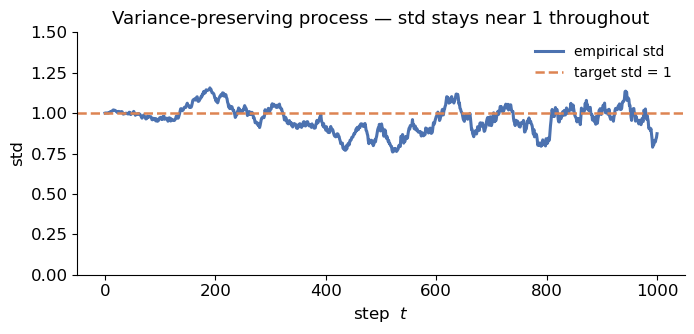

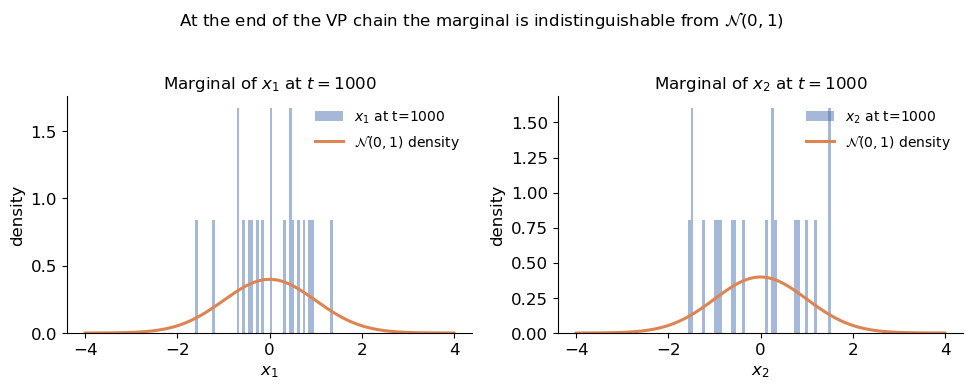

In [68]:
# ── VP std-vs-t ───────────────────────────────────────────────────────────────
t_arr_vp = np.arange(T_VP + 1)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t_arr_vp, vp_std, color=C_SAMPLE, lw=2.2, label="empirical std")
ax.axhline(1, color=C_ACCENT, lw=1.8, ls="--", label="target std = 1")
ax.set_ylim(0, 1.5)
ax.set_xlabel("step  $t$")
ax.set_ylabel("std")
ax.set_title("Variance-preserving process — std stays near 1 throughout", fontsize=13)
ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig10_vp_std_vs_t.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Convergence check: marginal histograms at T vs N(0,1) ────────────────────
x_final = vp_snaps[T_VP]
g_grid  = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for i, ax in enumerate(axes):
    ax.hist(x_final[:, i], bins=50, density=True,
            color=C_SAMPLE, alpha=0.5, label=f"$x_{i+1}$ at t={T_VP}")
    ax.plot(g_grid, sp_norm.pdf(g_grid, 0, 1),
            color=C_ACCENT, lw=2.2,
            label=r"$\mathcal{N}(0,1)$ density")
    ax.set_xlabel(f"$x_{i+1}$")
    ax.set_ylabel("density")
    ax.legend(fontsize=10, frameon=False)
    ax.set_title(f"Marginal of $x_{i+1}$ at $t = {T_VP}$", fontsize=12)

fig.suptitle(
    f"At the end of the VP chain the marginal is indistinguishable from $\mathcal{{N}}(0,1)$",
    fontsize=12, y=1.02,
)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig11_vp_convergence.png", dpi=200, bbox_inches="tight")
plt.show()

---
### DDPM step under the microscope: shrink first, then inject noise

Each VP update has **two sub-operations** that happen in sequence:

1. **Shrink the signal** — multiply `x_{t-1}` by `√(1 − β_t)`.  
   This contracts the entire cloud toward the origin. The structure (the S-shape,
   the colors) is preserved in miniature; only the scale changes.

2. **Inject noise** — add `√(β_t) · ε`, `ε ~ N(0, I)`.  
   This inflates a Gaussian halo around the shrunken cloud, restoring the total
   variance back to 1.

The balance shifts over time: early steps use `β_t ≈ 10⁻⁴`, so `√(1−β_t) ≈ 1`
(almost no shrink, almost no noise). Late steps use `β_t = 0.02`, so the shrink
is visible and the noise contribution is larger. The third column always has
std ≈ 1 — the two operations cancel each other out variance-wise.

The middle column — "signal only" — makes the contraction explicit. It is what
the model is trying to *invert* during the reverse (denoising) pass.

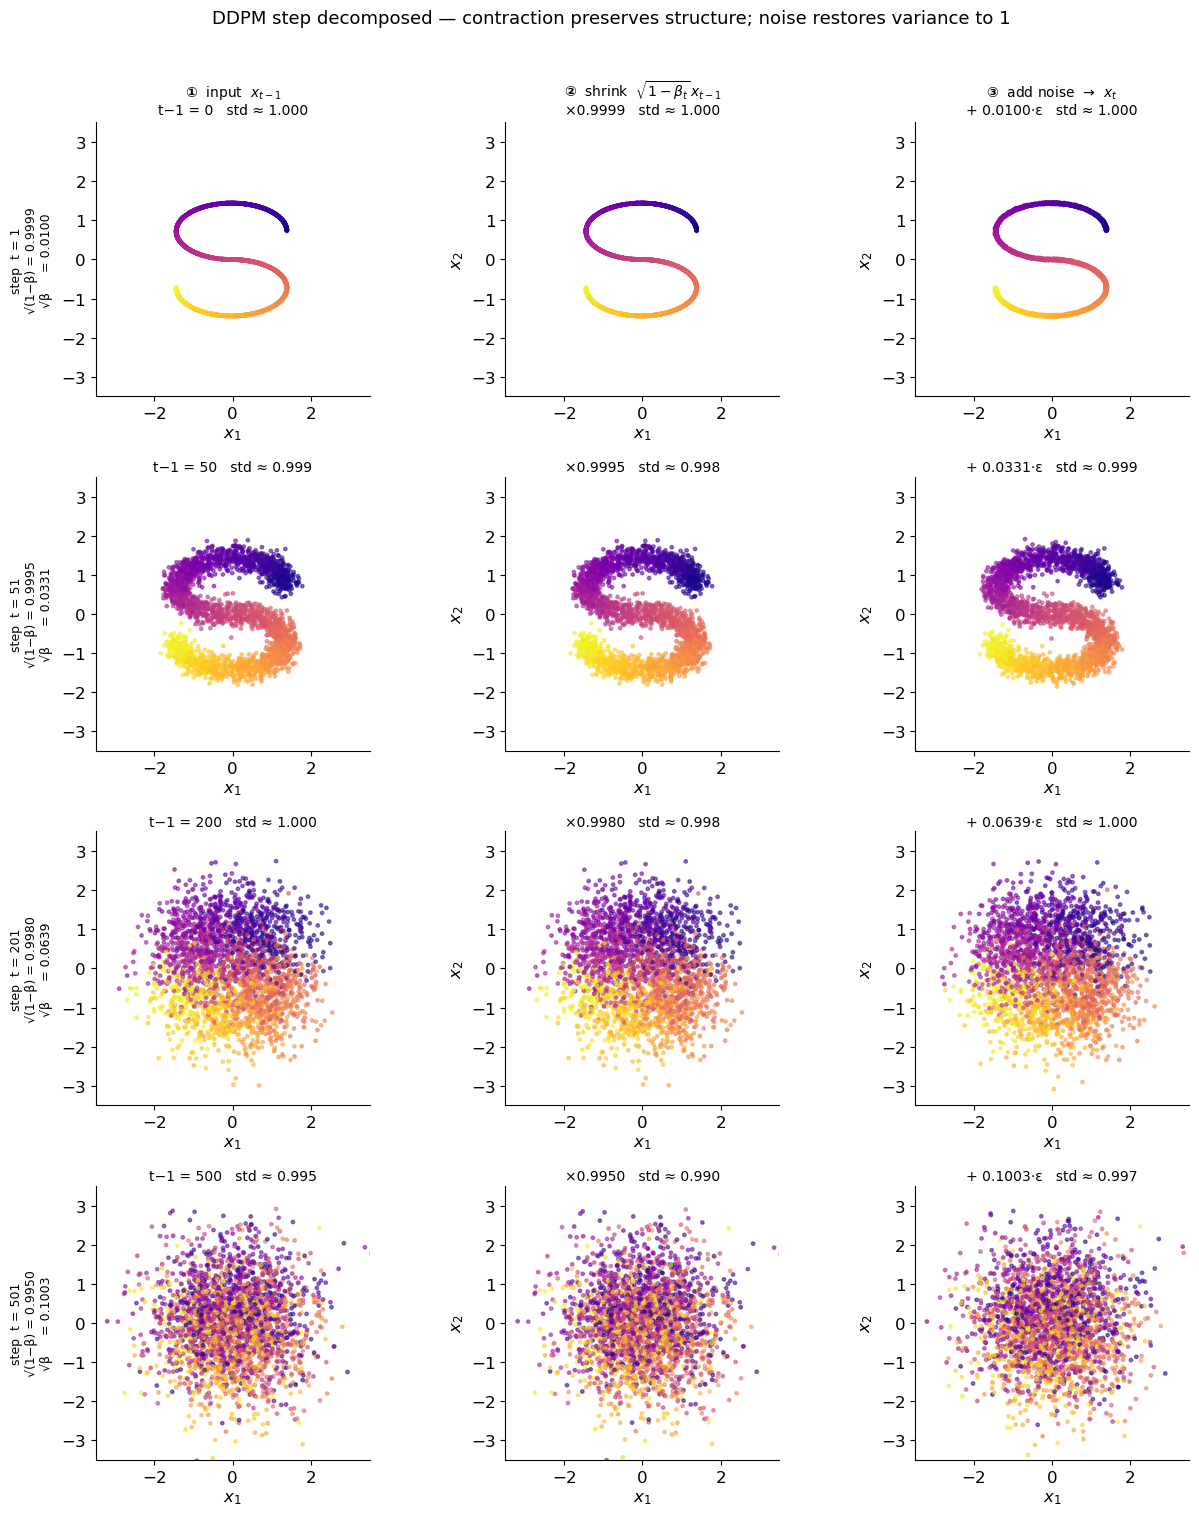

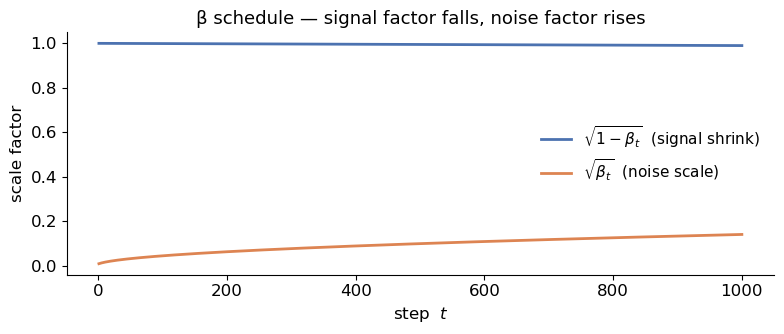

In [41]:
# ── DDPM step decomposed: shrink → noise at 4 representative timesteps ────────
# For each (t_prev, t_cur): take the stored snapshot x_{t-1} = vp_snaps[t_prev],
# compute the intermediate signal = √(1−β_t)·x_{t-1}, then add the noise term.
DEMO_STEPS = [(0, 1), (50, 51), (200, 201), (500, 501)]
RNG_DECOMP = np.random.default_rng(99)   # isolated seed → stable demo noise

fig, axes = plt.subplots(4, 3, figsize=(13, 15))

for row, (t_prev, t_cur) in enumerate(DEMO_STEPS):
    beta_t = BETA_VP[t_cur - 1]
    s_sig  = np.sqrt(1.0 - beta_t)   # signal shrink factor
    s_nse  = np.sqrt(beta_t)          # noise injection scale

    x_prev = vp_snaps[t_prev]
    signal = s_sig * x_prev                                  # step (1): shrink
    eps    = RNG_DECOMP.standard_normal(x_prev.shape)
    x_cur  = signal + s_nse * eps                            # step (2): noise

    # Panel titles show per-panel std so you can track the variance budget.
    scatter_snap(axes[row, 0], x_prev,
                 f"t−1 = {t_prev}   std ≈ {x_prev.std(axis=0).mean():.3f}")
    scatter_snap(axes[row, 1], signal,
                 f"×{s_sig:.4f}   std ≈ {signal.std(axis=0).mean():.3f}")
    scatter_snap(axes[row, 2], x_cur,
                 f"+ {s_nse:.4f}·ε   std ≈ {x_cur.std(axis=0).mean():.3f}")
    # Row label on leftmost panel: which step and what the two scale factors are
    axes[row, 0].set_ylabel(
        f"step  t = {t_cur}\n√(1−β) = {s_sig:.4f}\n√β     = {s_nse:.4f}",
        fontsize=9, labelpad=6,
    )

# Annotate column roles on the top row only
for ax, header in zip(axes[0], [
    r"$\mathbf{①}$  input  $x_{t-1}$",
    r"$\mathbf{②}$  shrink  $\sqrt{1-\beta_t}\, x_{t-1}$",
    r"$\mathbf{③}$  add noise  →  $x_t$",
]):
    ax.set_title(header + "\n" + ax.get_title(), fontsize=10)

fig.suptitle(
    "DDPM step decomposed — contraction preserves structure; noise restores variance to 1",
    fontsize=13, y=1.01,
)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig14_ddpm_step_decomp.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Schedule curves: how the two scale factors shift over t ───────────────────
t_sched = np.arange(1, T_VP + 1)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t_sched, np.sqrt(1 - BETA_VP), color=C_SAMPLE, lw=2,
        label=r"$\sqrt{1-\beta_t}$  (signal shrink)")
ax.plot(t_sched, np.sqrt(BETA_VP),     color=C_ACCENT, lw=2,
        label=r"$\sqrt{\beta_t}$  (noise scale)")
ax.set_xlabel("step  $t$")
ax.set_ylabel("scale factor")
ax.set_title("β schedule — signal factor falls, noise factor rises", fontsize=13)
ax.legend(fontsize=11, frameon=False)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig15_beta_schedule.png", dpi=200, bbox_inches="tight")
plt.show()

---
### Section D — The money shot: side-by-side comparison

Two rows at proportionally matched timesteps, **identical axis limits** (±3.5):

- **Top row (naive):** the cloud overflows the frame because variance explodes.
- **Bottom row (VP):** the cloud stays inside the frame, the S dissolves smoothly,
  and the final panel is a round unit blob centered at the origin.

The std-vs-t overlay makes the divergence quantitative: one curve shoots upward, the
other stays flat near 1 throughout the entire chain.

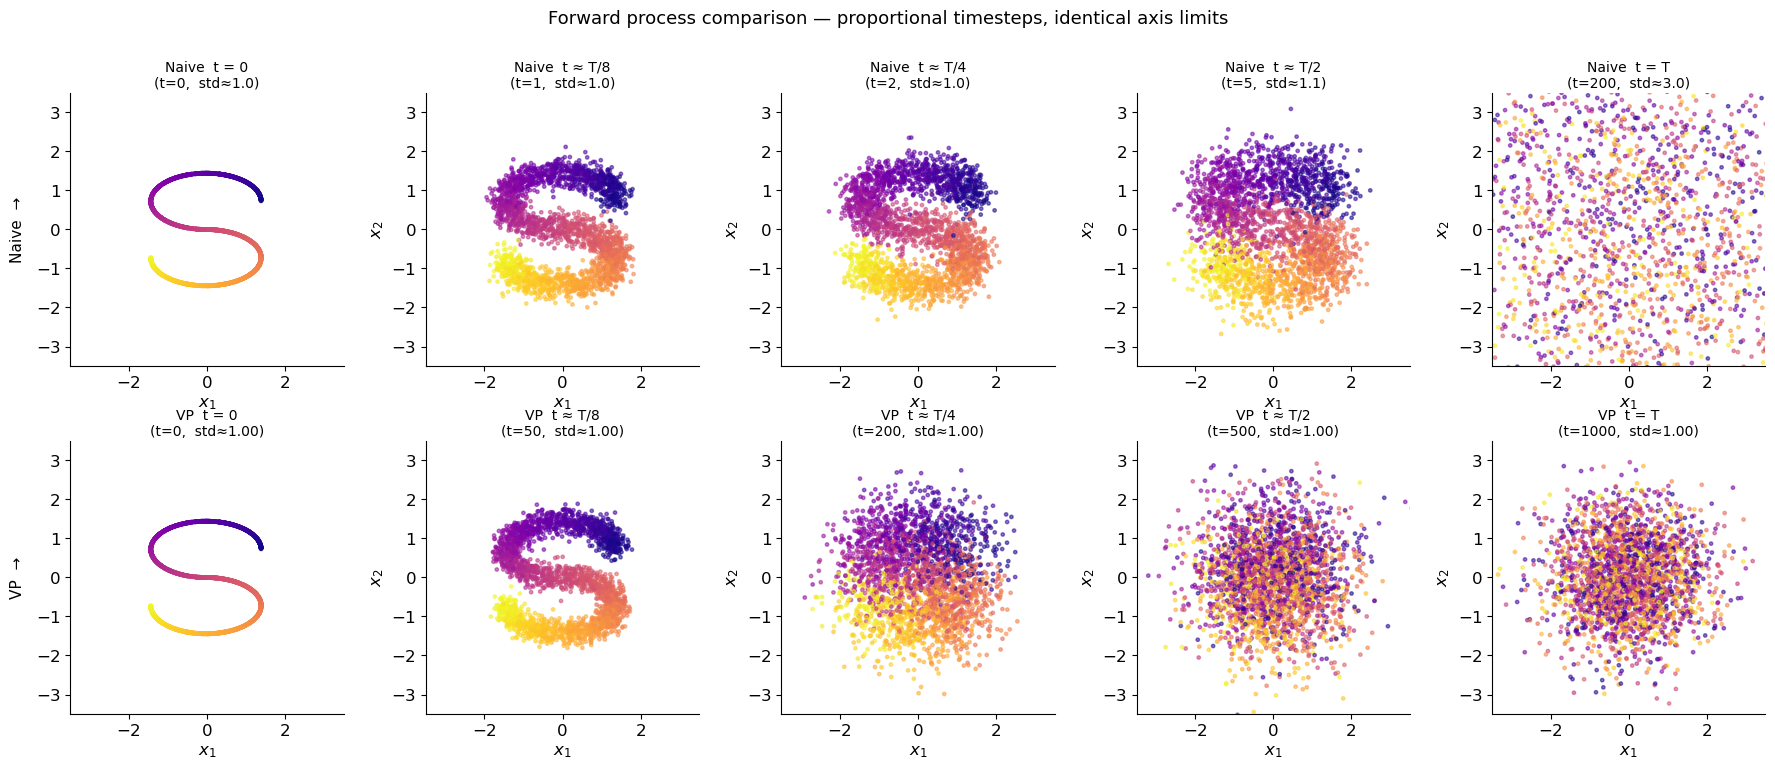

In [42]:
# Proportional snapshot pairs: naive [0,25,50,100,200] ↔ VP [0,50,200,500,1000]
MATCH = [
    ("t = 0",   SNAPS_N[0], SNAPS_VP[0]),
    ("t ≈ T/8", SNAPS_N[1], SNAPS_VP[1]),
    ("t ≈ T/4", SNAPS_N[2], SNAPS_VP[2]),
    ("t ≈ T/2", SNAPS_N[3], SNAPS_VP[3]),
    ("t = T",   SNAPS_N[4], SNAPS_VP[4]),
]

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for col, (label, t_n, t_vp) in enumerate(MATCH):
    # Top row: naive (overflows)
    scatter_snap(
        axes[0, col], naive_snaps[t_n],
        f"Naive  {label}\n(t={t_n},  std≈{naive_std[t_n]:.1f})",
    )
    # Bottom row: VP (stays put)
    scatter_snap(
        axes[1, col], vp_snaps[t_vp],
        f"VP  {label}\n(t={t_vp},  std≈{vp_std[t_vp]:.2f})",
    )

axes[0, 0].set_ylabel("Naive  →", fontsize=11, labelpad=8)
axes[1, 0].set_ylabel("VP  →",    fontsize=11, labelpad=8)

fig.suptitle(
    "Forward process comparison — proportional timesteps, identical axis limits",
    fontsize=13, y=1.01,
)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig12_comparison_panels.png", dpi=200, bbox_inches="tight")
plt.show()

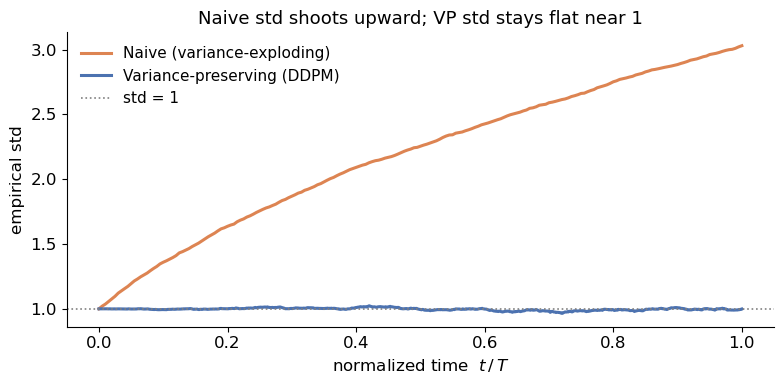

In [40]:
# ── Std curves on one axes — naive diverges, VP stays flat ───────────────────
# Rescale time to [0, 1] so both chains share the x-axis.
t_n_norm  = np.linspace(0, 1, T_N  + 1)
t_vp_norm = np.linspace(0, 1, T_VP + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_n_norm,  naive_std, color=C_ACCENT, lw=2.2,
        label="Naive (variance-exploding)")
ax.plot(t_vp_norm, vp_std,   color=C_SAMPLE, lw=2.2,
        label="Variance-preserving (DDPM)")
ax.axhline(1, color="gray", lw=1.2, ls=":", label="std = 1")
ax.set_xlabel("normalized time  $t\,/\,T$")
ax.set_ylabel("empirical std")
ax.set_title("Naive std shoots upward; VP std stays flat near 1", fontsize=13)
ax.legend(fontsize=11, frameon=False)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig13_comparison_std.png", dpi=200, bbox_inches="tight")
plt.show()

# Looking at force field 

In [126]:
from sklearn.datasets import make_s_curve
from scipy.stats import norm as sp_norm

# Dedicated RNG for the noising experiments — decoupled from Figures 1–5 above.
RNG_NOISE = np.random.default_rng(2024)

# Alternative 2D shapes (easy swaps for make_s_curve below):
#   make_moons(n_samples=2500, noise=0.0, random_state=42)   # two crescents
#   theta = np.linspace(0, 4*np.pi, 2500); r = theta / 12    # Archimedean spiral
X_raw, t_param = make_s_curve(n_samples=2000, noise=0.0, random_state=42)
data_raw = X_raw[:, [0, 2]]   # keep x and z; drop y → 2D "S"

# Normalize per-coordinate to zero mean, unit variance.
# The VP process converges to N(0,I) only when the data is properly scaled —
# "variance pinned at 1" is literally true only after normalization.
data = (data_raw - data_raw.mean(axis=0)) / data_raw.std(axis=0)

# Fixed point colormap: position along the S parameter → color.
# This mapping never changes across plots, so structure-dissolution
# shows up as color scrambling rather than just point movement.
CMAP_DATA = plt.cm.plasma
t_norm_param = (t_param - t_param.min()) / (t_param.max() - t_param.min())
POINT_COLORS = CMAP_DATA(t_norm_param)

# Shared axis limits — wide enough to frame the clean S, tight enough
# that the exploding cloud is visibly overflowing.
AX_LIM = (-3.5, 3.5)


def scatter_snap(ax, pts, title, ax_lim=AX_LIM):
    """Scatter one 2D snapshot with fixed point colors and equal aspect."""
    ax.scatter(pts[:, 0], pts[:, 1],
               c=POINT_COLORS, s=50, alpha=0.75, rasterized=True)
    ax.set_aspect("equal")
    ax.set_xlim(ax_lim); ax.set_ylim(ax_lim)
    ax.set_title(title, fontsize=10, pad=4)
    ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")


print(f"data shape : {data.shape}")
print(f"per-coord mean : {data.mean(0).round(4)},  std : {data.std(0).round(4)}")

data shape : (2000, 2)
per-coord mean : [-0.  0.],  std : [1. 1.]


In [129]:
# forward and backward process GIFs with adjustable force-field arrows

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ------------------------------------------------------------------------------
# Assumptions:
# - data:      numpy array of shape (N, 2)
# - RNG_NOISE: numpy random generator, e.g. np.random.default_rng(0)
# - FIG_DIR:   output directory
# ------------------------------------------------------------------------------

os.makedirs(FIG_DIR, exist_ok=True)

# ──────────────────────────────────────────────────────────────────────────────
# Adjustable plotting parameters
# ──────────────────────────────────────────────────────────────────────────────

POINT_SIZE  = 50
POINT_ALPHA = 0.75

# Force-field arrow controls
ARROW_DENSITY = 20        # larger = more arrows, e.g. 10, 15, 25
ARROW_SIZE    = 0.15      # larger = longer arrows, e.g. 0.2, 0.35, 0.6
ARROW_THICKNESS = 0.005   # larger = thicker arrows, e.g. 0.002, 0.004, 0.008
ARROW_ALPHA   = 0.75      # transparency of arrows
NORMALIZE_ARROWS = True   # True = show direction clearly; False = show true magnitude

# GIF controls
FPS = 10
FIG_SIZE = (6, 6)

# ──────────────────────────────────────────────────────────────────────────────
# Variance-preserving forward process
# ──────────────────────────────────────────────────────────────────────────────

T_VP      = 40
BETA_VP   = np.linspace(1e-4, 0.02, T_VP)
ALPHA_VP  = 1.0 - BETA_VP
ALPHA_BAR = np.cumprod(ALPHA_VP)

# Save only some steps for animation
FRAME_STEPS = list(range(0, T_VP + 1, 1))
if FRAME_STEPS[-1] != T_VP:
    FRAME_STEPS.append(T_VP)

vp_frames = {}
vp_std    = np.zeros(T_VP + 1)

x = data.copy()
vp_frames[0] = x.copy()
vp_std[0]    = x.std(axis=0).mean()

for t in range(1, T_VP + 1):
    eps = RNG_NOISE.standard_normal(x.shape)

    # Discrete VP/DDPM-style forward step
    x = np.sqrt(ALPHA_VP[t - 1]) * x + np.sqrt(BETA_VP[t - 1]) * eps

    vp_std[t] = x.std(axis=0).mean()

    if t in FRAME_STEPS:
        vp_frames[t] = x.copy()

times_forward  = FRAME_STEPS
times_backward = FRAME_STEPS[::-1]

# ──────────────────────────────────────────────────────────────────────────────
# Fixed plotting limits across all frames
# ──────────────────────────────────────────────────────────────────────────────

all_pts = np.vstack([vp_frames[t] for t in FRAME_STEPS])

xmin, ymin = all_pts.min(axis=0)
xmax, ymax = all_pts.max(axis=0)

cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
half_range = max(xmax - xmin, ymax - ymin) / 2
half_range *= 0.70

xlim = (cx - half_range, cx + half_range)
ylim = (cy - half_range, cy + half_range)

# ──────────────────────────────────────────────────────────────────────────────
# Force-field grid
# ──────────────────────────────────────────────────────────────────────────────

gx = np.linspace(xlim[0], xlim[1], ARROW_DENSITY)
gy = np.linspace(ylim[0], ylim[1], ARROW_DENSITY)
GX, GY = np.meshgrid(gx, gy)

EPS_NORM = 1e-8

def get_beta_for_step(t):
    """
    t is in [0, T_VP].
    Use beta_1 for t=0 just for visualization.
    """
    idx = max(0, min(T_VP - 1, t - 1))
    return BETA_VP[idx]


def force_field(t, mode="forward"):
    """
    Forward force:
        F(x,t) = -1/2 beta(t) x

    Flipped force for educational reverse visualization:
        -F(x,t) = +1/2 beta(t) x
    """
    beta_t = get_beta_for_step(t)

    if mode == "forward":
        U = -0.5 * beta_t * GX
        V = -0.5 * beta_t * GY
    elif mode == "backward":
        U = +0.5 * beta_t * GX
        V = +0.5 * beta_t * GY
    else:
        raise ValueError("mode must be 'forward' or 'backward'")

    if NORMALIZE_ARROWS:
        norm = np.sqrt(U**2 + V**2) + EPS_NORM
        U = ARROW_SIZE * U / norm
        V = ARROW_SIZE * V / norm

    return U, V


# ──────────────────────────────────────────────────────────────────────────────
# Helper functions
# ──────────────────────────────────────────────────────────────────────────────

def setup_ax(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)


def make_gif(times, out_path, mode="forward", fps=FPS):
    fig, ax = plt.subplots(figsize=FIG_SIZE)

    # Remove all figure padding
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    setup_ax(ax)

    t0 = times[0]
    pts0 = vp_frames[t0]

    U0, V0 = force_field(t0, mode=mode)

    quiv = ax.quiver(
        GX,
        GY,
        U0,
        V0,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=ARROW_THICKNESS,
        alpha=ARROW_ALPHA,
        color='green',
        zorder=1
    )

    scat = ax.scatter(
        pts0[:, 0],
        pts0[:, 1],
        c=np.linspace(0, 1, len(pts0)),
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        cmap="plasma",
        edgecolors="none",
        zorder=3
    )

    def update(i):
        t = times[i]
        pts = vp_frames[t]

        U, V = force_field(t, mode=mode)

        scat.set_offsets(pts)
        quiv.set_UVC(U, V)

        return scat, quiv

    anim = FuncAnimation(
        fig,
        update,
        frames=len(times),
        interval=100,
        blit=True
    )

    anim.save(
        out_path,
        writer=PillowWriter(fps=fps),
        savefig_kwargs={
            "bbox_inches": "tight",
            "pad_inches": 0
        }
    )

    plt.close(fig)


# ──────────────────────────────────────────────────────────────────────────────
# Save GIFs
# ──────────────────────────────────────────────────────────────────────────────

forward_gif = os.path.join(FIG_DIR, "vp_forward_with_F.gif")
make_gif(
    times_forward,
    forward_gif,
    mode="forward",
    fps=FPS
)

backward_gif = os.path.join(FIG_DIR, "vp_backward_with_minus_F.gif")
make_gif(
    times_backward,
    backward_gif,
    mode="backward",
    fps=FPS
)

print("Saved GIFs:")
print(forward_gif)
print(backward_gif)

Saved GIFs:
./figures/vp_forward_with_F.gif
./figures/vp_backward_with_minus_F.gif
